In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/raw_data.csv")
df.head()

,OrderID,Date,Customer,Region,Sales,Category
0,1001,2024/01/05,Amit,West,1200.0,Electronics
1,1002,05-01-2024,Riya,North,NaN,Furniture
2,1003,2024-01-07,Arjun,South,850.0,electronics
3,1003,2024-01-07,Arjun,South,850.0,electronics
4,1004,NaN,Neha,West,1400.0,Furniture


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Shape: (15, 6)

Missing values:
 OrderID     0
Date        1
Customer    1
Region      1
Sales       3
Category    0
dtype: int64

Duplicates: 1

Data types:
 OrderID       int64
Date         object
Customer     object
Region       object
Sales       float64
Category     object
dtype: object


In [4]:
df_clean = df.copy()

# Removing duplicates
df_clean = df_clean.drop_duplicates()

# Standardizing text columns
df_clean["Region"] = df_clean["Region"].astype(str).str.strip().str.title()
df_clean["Category"] = df_clean["Category"].astype(str).str.strip().str.title()
df_clean["Customer"] = df_clean["Customer"].fillna("Unknown").astype(str).str.strip().str.title()

# Replacing invalid text created from NaN conversion
df_clean["Region"] = df_clean["Region"].replace("Nan", "Unknown")
df_clean["Category"] = df_clean["Category"].replace("Nan", "Unknown")

df_clean.head()

,OrderID,Date,Customer,Region,Sales,Category
0,1001,2024/01/05,Amit,West,1200.0,Electronics
1,1002,05-01-2024,Riya,North,NaN,Furniture
2,1003,2024-01-07,Arjun,South,850.0,Electronics
4,1004,NaN,Neha,West,1400.0,Furniture
5,1005,2024/01/10,Karan,East,2000.0,Technology


In [5]:
# Converting dates
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce", dayfirst=True)

# Filling missing dates with forward fill
df_clean["Date"] = df_clean["Date"].fillna(method="ffill")

# Converting sales to numeric
df_clean["Sales"] = pd.to_numeric(df_clean["Sales"], errors="coerce")

# Filling missing sales with median
df_clean["Sales"] = df_clean["Sales"].fillna(df_clean["Sales"].median())

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 0 to 14
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   OrderID   14 non-null     int64         
 1   Date      14 non-null     datetime64[ns]
 2   Customer  14 non-null     object        
 3   Region    14 non-null     object        
 4   Sales     14 non-null     float64       
 5   Category  14 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 784.0+ bytes


/tmp/ipykernel_14118/1812934667.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["Date"] = df_clean["Date"].fillna(method="ffill")


In [6]:
print("After cleaning:")
print("Shape:", df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())
print("\nDuplicates:", df_clean.duplicated().sum())

After cleaning:
Shape: (14, 6)

Missing values:
 OrderID     0
Date        0
Customer    0
Region      0
Sales       0
Category    0
dtype: int64

Duplicates: 0


In [7]:
region_summary = df_clean.groupby("Region")["Sales"].sum().reset_index()
category_summary = df_clean.groupby("Category")["Sales"].sum().reset_index()

print("Sales by Region:")
print(region_summary)

print("\nSales by Category:")
print(category_summary)

Sales by Region:
    Region   Sales
0     East  4200.0
1    North  6400.0
2    South  4500.0
3  Unknown  2100.0
4     West  5400.0

Sales by Category:
      Category   Sales
0  Electronics  7300.0
1    Furniture  7400.0
2   Technology  7900.0


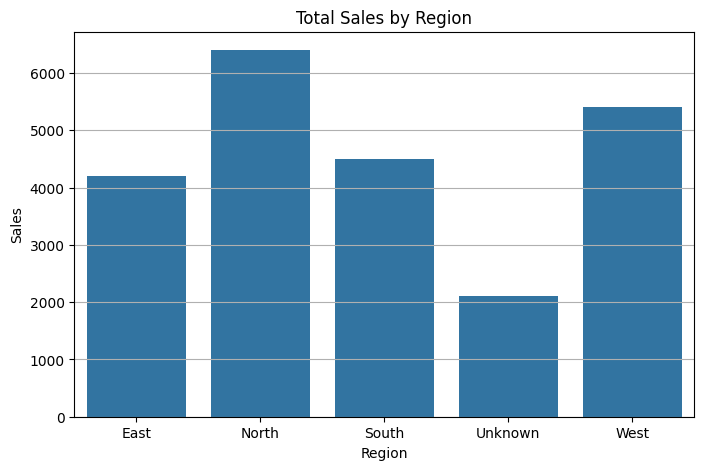

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x="Region", y="Sales")
plt.title("Total Sales by Region")
plt.grid(axis="y")
plt.show()

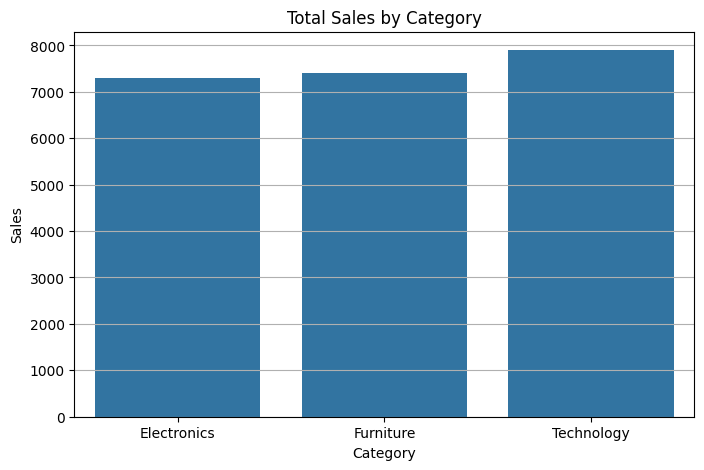

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_summary, x="Category", y="Sales")
plt.title("Total Sales by Category")
plt.grid(axis="y")
plt.show()

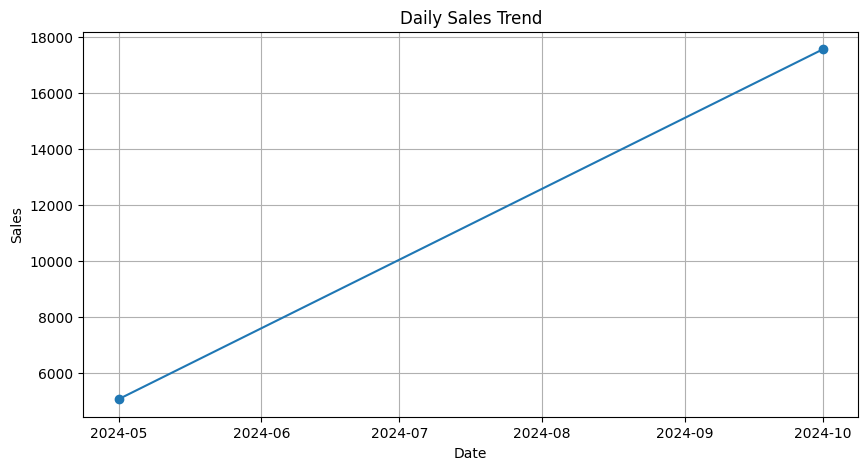

In [10]:
daily_sales = df_clean.groupby("Date")["Sales"].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"], marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [11]:
df_clean.to_csv("cleaned_data.csv", index=False)
print("cleaned_data.csv saved successfully")

cleaned_data.csv saved successfully
